
# TS2Vec Serious Experiment: Regime Clustering And Anomaly Detection

This notebook prepares a **longer, research-style TS2Vec experiment** on the frozen 24h terminal release. It is intentionally focused on **embedding-native tasks**, not outcome classification.

Main objectives:

1. Learn a stronger TS2Vec representation from a larger train universe.
2. Cluster markets into interpretable trajectory regimes:
   - `stable_yes`
   - `stable_no`
   - `late_breakout`
   - `pump_and_revert`
   - `noisy_coinflip`
3. Use the learned embedding geometry for anomaly and regime-shift detection:
   - unusually sharp moves
   - atypical reversals
   - strange late dynamics before resolution

This notebook does **not** modify benchmark code or release artifacts. It only reads:

- `benchmark_releases/polymarket/terminal/v1`
- the cloned `ts2vec/` implementation at repo root



## Experimental Design

The setup is deliberately closer to a real representation-learning study than the earlier demo notebook.

- Training is **self-supervised** on the `train` split only.
- Analysis is performed on a wider universe, by default the full train+test artifact.
- We use a longer context window than the showcase notebook: **14 days before the 24h cutoff**, sampled every **2 hours**.
- TS2Vec sees only the market path, so the interpretation target is **trajectory geometry**, not question semantics.

Recommended runtime expectations:

- default settings are aimed at a **real but still manageable run**: roughly `3-4` epochs and often around **~30 minutes** on CPU, depending on hardware and universe size
- on GPU it should be materially faster
- if needed, reduce `TRAIN_MARKET_CAP`, `ANALYSIS_MARKET_CAP`, or `LOOKBACK_HOURS`

Important methodological note:

- the model is **not** told in advance that clusters should be `stable_yes`, `stable_no`, `late_breakout`, `pump_and_revert`, or `noisy_coinflip`
- TS2Vec first learns embeddings self-supervised, then `KMeans` finds clusters in that embedding space
- only **after** clustering do we assign human-readable names to the discovered clusters using aggregate path statistics


In [1]:

import os
import sys
import warnings
from contextlib import contextmanager
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

try:
    import torch
except ImportError as exc:
    raise RuntimeError(
        "This notebook requires a kernel with torch installed. "
        "Use the polymarket conda env, e.g. /Users/sneddy/anaconda3/envs/polymarket/bin/python."
    ) from exc

from polymarket_research.benchmarks.io.paths import DEFAULT_BENCHMARK_RELEASE_VERSION, benchmark_release_dir
from polymarket_research.utils.filesystem import setup_root

REPO_ROOT = setup_root()
DATA_SOURCE = "polymarket"
RELEASE_VERSION = DEFAULT_BENCHMARK_RELEASE_VERSION
TS2VEC_SRC = REPO_ROOT / "ts2vec"
BENCHMARK_RELEASE_DIR = benchmark_release_dir(REPO_ROOT, source=DATA_SOURCE, task="terminal", version=RELEASE_VERSION)
EXAMPLES_PATH = BENCHMARK_RELEASE_DIR / "examples.parquet"
HISTORY_PATH = BENCHMARK_RELEASE_DIR / "market_timeseries.parquet"

if str(TS2VEC_SRC) not in sys.path:
    sys.path.insert(0, str(TS2VEC_SRC))

from ts2vec import TS2Vec

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
np.set_printoptions(precision=4, suppress=True)
warnings.filterwarnings("ignore", message=".*All-NaN slice encountered.*")
warnings.filterwarnings("ignore", message=".*Mean of empty slice.*")

SEED = 7
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RNG = np.random.default_rng(SEED)

TRAIN_MARKET_CAP = 4000
ANALYSIS_MARKET_CAP = None
USE_MOST_RECENT_WHEN_CAPPED = True

LOOKBACK_HOURS = 24 * 14
GRID_HOURS = 2
PRICE_CLIP = 1e-3

N_EPOCHS = 4
OUTPUT_DIMS = 128
HIDDEN_DIMS = 64
DEPTH = 10
BATCH_SIZE = 32 if DEVICE == "cpu" else 64
ENCODE_BATCH_SIZE = 256 if DEVICE == "cpu" else 1024

REGIME_NAMES = [
    "stable_yes",
    "stable_no",
    "late_breakout",
    "pump_and_revert",
    "noisy_coinflip",
]
FINAL_REGIME_K = 5
REGIME_CLUSTER_CANDIDATES = (4, 5, 6, 7, 8)
CLUSTER_SELECTION_SAMPLE = 1500

KNN_NEIGHBORS = 10
TOP_ANOMALIES = 12
TOP_REPRESENTATIVES = 5
ANOMALY_NEIGHBORS = 5

np.random.seed(SEED)
torch.manual_seed(SEED)

@contextmanager
def suppress_stderr():
    old_stderr = os.dup(2)
    try:
        with open(os.devnull, "w", encoding="utf-8") as devnull:
            os.dup2(devnull.fileno(), 2)
            yield
    finally:
        os.dup2(old_stderr, 2)
        os.close(old_stderr)


def quiet_read_parquet(path, **kwargs):
    with suppress_stderr():
        return pd.read_parquet(path, **kwargs)


def choose_market_universe(frame, *, split=None, cap=None, newest_first=True):
    out = frame.copy()
    if split is not None:
        out = out.loc[out["split"] == split].copy()
    out = out.sort_values(["cutoff_timestamp_utc", "market_id"], kind="stable").reset_index(drop=True)
    if cap is None or len(out) <= cap:
        return out.reset_index(drop=True)
    return out.tail(cap).reset_index(drop=True) if newest_first else out.head(cap).reset_index(drop=True)


def load_histories_for_market_ids(market_ids):
    history = quiet_read_parquet(
        HISTORY_PATH,
        filters=[("market_id", "in", [str(x) for x in market_ids])],
        columns=["market_id", "timestamp_utc", "yes_probability"],
    )
    history["timestamp_utc"] = pd.to_datetime(history["timestamp_utc"], utc=True, errors="coerce")
    history = history.dropna(subset=["timestamp_utc"]).copy()
    return {
        str(market_id): group.sort_values("timestamp_utc").drop_duplicates("timestamp_utc", keep="last").reset_index(drop=True)
        for market_id, group in history.groupby("market_id", sort=False)
    }


def build_sequence(history, cutoff_timestamp, *, lookback_hours, grid_hours):
    cutoff = pd.Timestamp(cutoff_timestamp)
    start = cutoff - pd.Timedelta(hours=lookback_hours)
    prefix = history.loc[(history["timestamp_utc"] >= start) & (history["timestamp_utc"] <= cutoff)].copy()
    prefix = prefix.sort_values("timestamp_utc").drop_duplicates("timestamp_utc", keep="last")
    if prefix.empty:
        raise ValueError("No history available inside lookback window.")

    grid = pd.date_range(start=start, end=cutoff, freq=f"{grid_hours}h", tz="UTC")
    aligned = pd.merge_asof(
        pd.DataFrame({"grid_time": grid}),
        prefix.rename(columns={"timestamp_utc": "obs_time"}),
        left_on="grid_time",
        right_on="obs_time",
        direction="backward",
        allow_exact_matches=True,
    )

    raw_price = aligned["yes_probability"].to_numpy(dtype=np.float32)
    obs_time = pd.to_datetime(aligned["obs_time"], utc=True, errors="coerce")
    staleness_hours = (aligned["grid_time"] - obs_time).dt.total_seconds().to_numpy(dtype=np.float32) / 3600.0

    valid = ~np.isnan(raw_price)
    if not valid.any():
        raise ValueError("Sequence has no observed points.")

    delta = np.full(raw_price.shape, np.nan, dtype=np.float32)
    first_valid = int(np.flatnonzero(valid)[0])
    delta[first_valid] = 0.0
    if first_valid + 1 < len(raw_price):
        delta[1:] = np.where(valid[1:] & valid[:-1], np.diff(raw_price), np.nan).astype(np.float32)

    price_level = np.full(raw_price.shape, np.nan, dtype=np.float32)
    clipped = np.clip(raw_price[valid], PRICE_CLIP, 1.0 - PRICE_CLIP)
    price_level[valid] = np.log(clipped / (1.0 - clipped)).astype(np.float32)

    gap = np.full(raw_price.shape, np.nan, dtype=np.float32)
    gap[valid] = np.minimum(staleness_hours[valid], lookback_hours).astype(np.float32)

    delta_abs = np.where(np.isnan(delta), np.nan, np.abs(delta)).astype(np.float32)
    features = np.stack([price_level, delta, delta_abs, gap], axis=-1).astype(np.float32)
    stats = {
        "observed_steps": int(valid.sum()),
        "coverage_ratio": float(valid.mean()),
        "last_price": float(raw_price[valid][-1]),
        "start_price": float(raw_price[valid][0]),
    }
    return features, raw_price.astype(np.float32), valid.astype(bool), stats


def build_tensor(example_frame, histories_by_market, *, lookback_hours, grid_hours):
    features, raw_prices, valid_masks, rows = [], [], [], []
    for row in example_frame.to_dict("records"):
        market_id = str(row["market_id"])
        feat, raw_price, valid_mask, stats = build_sequence(
            histories_by_market[market_id],
            row["cutoff_timestamp_utc"],
            lookback_hours=lookback_hours,
            grid_hours=grid_hours,
        )
        features.append(feat)
        raw_prices.append(raw_price)
        valid_masks.append(valid_mask)
        rows.append(
            {
                "market_id": market_id,
                "question": row["question"],
                "split": row["split"],
                "cutoff_timestamp_utc": pd.Timestamp(row["cutoff_timestamp_utc"]),
                **stats,
            }
        )
    return (
        np.stack(features).astype(np.float32),
        np.stack(raw_prices).astype(np.float32),
        np.stack(valid_masks).astype(bool),
        pd.DataFrame(rows),
    )


def standardize_tensor(train_tensor, analysis_tensor):
    flat = train_tensor.reshape(-1, train_tensor.shape[-1])
    means = np.nanmean(flat, axis=0)
    stds = np.nanstd(flat, axis=0)
    stds = np.where(stds < 1e-6, 1.0, stds)
    return (train_tensor - means) / stds, (analysis_tensor - means) / stds, means, stds


def fit_ts2vec(train_tensor):
    model = TS2Vec(
        input_dims=train_tensor.shape[-1],
        output_dims=OUTPUT_DIMS,
        hidden_dims=HIDDEN_DIMS,
        depth=DEPTH,
        device=DEVICE,
        batch_size=BATCH_SIZE,
        lr=1e-3,
        max_train_length=train_tensor.shape[1],
        temporal_unit=0,
    )
    loss_log = model.fit(train_tensor, n_epochs=N_EPOCHS, verbose=True)
    return model, loss_log


def batched_encode_full_series(model, tensor, *, batch_size):
    outputs = []
    for start in range(0, len(tensor), batch_size):
        batch = tensor[start : start + batch_size]
        encoded = np.asarray(model.encode(batch, encoding_window="full_series"))
        outputs.append(encoded.reshape(encoded.shape[0], -1))
    return np.vstack(outputs)


def pool_window(z_row, valid_mask_row, start_frac, end_frac):
    valid_idx = np.flatnonzero(valid_mask_row)
    if len(valid_idx) == 0:
        return np.full(z_row.shape[-1], np.nan, dtype=np.float32)
    start = int(np.floor(len(valid_idx) * start_frac))
    stop = int(np.ceil(len(valid_idx) * end_frac))
    stop = max(stop, start + 1)
    chosen = valid_idx[start:stop]
    if len(chosen) == 0:
        chosen = valid_idx[-1:]
    return z_row[chosen].mean(axis=0).astype(np.float32)


def batched_encode_window_poolings(model, tensor, valid_masks, *, batch_size):
    early_rows, mid_rows, late_rows = [], [], []
    for start in range(0, len(tensor), batch_size):
        batch = tensor[start : start + batch_size]
        batch_valid = valid_masks[start : start + batch_size]
        z = np.asarray(model.encode(batch))
        for row_repr, row_valid in zip(z, batch_valid):
            early_rows.append(pool_window(row_repr, row_valid, 0.00, 0.33))
            mid_rows.append(pool_window(row_repr, row_valid, 0.33, 0.66))
            late_rows.append(pool_window(row_repr, row_valid, 0.66, 1.00))
    return {
        "early": np.vstack(early_rows),
        "mid": np.vstack(mid_rows),
        "late": np.vstack(late_rows),
    }


def cosine_distance(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(1.0 - np.dot(a, b) / denom)


def zscore_series(values):
    values = pd.Series(values, dtype=float)
    std = values.std(ddof=0)
    if std < 1e-12:
        return pd.Series(np.zeros(len(values)), index=values.index, dtype=float)
    return (values - values.mean()) / std


In [2]:

def path_statistics(price_row, valid_mask_row):
    prices = price_row[valid_mask_row]
    if len(prices) == 0:
        raise ValueError("Empty observed path.")

    diffs = np.diff(prices) if len(prices) > 1 else np.array([0.0], dtype=np.float32)
    abs_diffs = np.abs(diffs)
    start = float(prices[0])
    end = float(prices[-1])
    path_range = float(np.max(prices) - np.min(prices))
    net_change = float(end - start)
    reversal_index = float(max(path_range - abs(net_change), 0.0))
    max_abs_step = float(abs_diffs.max()) if len(abs_diffs) else 0.0
    realized_vol = float(np.std(diffs)) if len(diffs) else 0.0

    sign = np.sign(diffs)
    nz_sign = sign[sign != 0]
    if len(nz_sign) <= 1:
        sign_change_rate = 0.0
    else:
        sign_change_rate = float(np.mean(nz_sign[1:] != nz_sign[:-1]))

    q = max(1, len(prices) // 4)
    early_mean = float(prices[:q].mean())
    late_mean = float(prices[-q:].mean())
    middle = prices[len(prices) // 3 : max(len(prices) // 3 + 1, 2 * len(prices) // 3)]
    mid_mean = float(middle.mean()) if len(middle) else float(prices.mean())

    final_window = prices[-max(1, int(24 / GRID_HOURS)) :]
    prev_window = prices[-max(2, int(48 / GRID_HOURS)) : -max(1, int(24 / GRID_HOURS))]
    if len(prev_window) == 0:
        prev_window = prices[: max(1, int(24 / GRID_HOURS))]
    last_day_range = float(np.max(final_window) - np.min(final_window))
    last_day_change = float(final_window.mean() - prev_window.mean())

    pump_and_revert_score = float(path_range * max(1.0 - abs(net_change) / (path_range + 1e-6), 0.0))
    coinflip_share = float(np.mean((prices >= 0.35) & (prices <= 0.65)))
    breakout_score = float(late_mean - early_mean)

    return {
        "start_price": start,
        "end_price": end,
        "net_change": net_change,
        "path_range": path_range,
        "reversal_index": reversal_index,
        "pump_and_revert_score": pump_and_revert_score,
        "max_abs_step": max_abs_step,
        "realized_vol": realized_vol,
        "sign_change_rate": sign_change_rate,
        "coinflip_share": coinflip_share,
        "early_mean": early_mean,
        "mid_mean": mid_mean,
        "late_mean": late_mean,
        "breakout_score": breakout_score,
        "last_day_range": last_day_range,
        "last_day_change": last_day_change,
    }


def build_market_feature_frame(meta_frame, raw_prices, valid_masks):
    rows = []
    for meta_row, price_row, valid_mask_row in zip(meta_frame.to_dict("records"), raw_prices, valid_masks):
        rows.append({**meta_row, **path_statistics(price_row, valid_mask_row)})
    return pd.DataFrame(rows)


def choose_cluster_count(embeddings, candidates, *, sample_size, seed):
    rng = np.random.default_rng(seed)
    if len(embeddings) > sample_size:
        sample_idx = np.sort(rng.choice(len(embeddings), size=sample_size, replace=False))
        sample = embeddings[sample_idx]
    else:
        sample = embeddings

    rows = []
    for k in candidates:
        model = KMeans(n_clusters=k, random_state=seed, n_init=30)
        labels = model.fit_predict(sample)
        rows.append(
            {
                "k": int(k),
                "inertia": float(model.inertia_),
                "calinski_harabasz": float(calinski_harabasz_score(sample, labels)),
                "davies_bouldin": float(davies_bouldin_score(sample, labels)),
            }
        )
    out = pd.DataFrame(rows)
    out["ch_rank"] = out["calinski_harabasz"].rank(ascending=False, method="dense")
    out["db_rank"] = out["davies_bouldin"].rank(ascending=True, method="dense")
    out["combined_rank"] = out["ch_rank"] + out["db_rank"]
    return out.sort_values("k").reset_index(drop=True)


# Post hoc naming only: clusters are discovered unsupervised, then matched to interpretable regime names.
def template_score(row, regime_name):
    if regime_name == "stable_yes":
        return 2.2 * row["end_mean"] - 0.9 * row["path_range_mean"] - 0.8 * row["coinflip_share_mean"]
    if regime_name == "stable_no":
        return 2.2 * (1.0 - row["end_mean"]) - 0.9 * row["path_range_mean"] - 0.8 * row["coinflip_share_mean"]
    if regime_name == "late_breakout":
        return 1.6 * row["breakout_score_mean"] + 1.0 * row["last_day_change_mean"] + 0.5 * row["late_shift_mean"]
    if regime_name == "pump_and_revert":
        return 1.7 * row["pump_and_revert_score_mean"] + 0.8 * row["reversal_index_mean"] + 0.4 * row["early_late_drift_mean"]
    if regime_name == "noisy_coinflip":
        return 1.6 * row["coinflip_share_mean"] + 1.2 * row["realized_vol_mean"] - 0.8 * abs(row["end_mean"] - 0.5)
    raise KeyError(regime_name)


def assign_named_regimes(cluster_summary):
    remaining = set(cluster_summary["cluster"].tolist())
    assignments = {}
    score_rows = []
    for regime_name in REGIME_NAMES:
        scored = []
        for cluster_id in remaining:
            row = cluster_summary.loc[cluster_summary["cluster"] == cluster_id].iloc[0]
            scored.append((template_score(row, regime_name), int(cluster_id)))
        best_score, best_cluster = max(scored, key=lambda item: item[0])
        assignments[best_cluster] = regime_name
        score_rows.append({"cluster": best_cluster, "named_regime": regime_name, "template_score": float(best_score)})
        remaining.remove(best_cluster)
    return assignments, pd.DataFrame(score_rows)


def nearest_neighbor_tables(embeddings, feature_frame, *, n_neighbors):
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1, metric="euclidean")
    nn.fit(embeddings)
    distances, indices = nn.kneighbors(embeddings)
    feature_frame = feature_frame.copy()
    feature_frame["mean_knn_distance"] = distances[:, 1:].mean(axis=1)
    return feature_frame, distances[:, 1:], indices[:, 1:]


def anomaly_neighbor_table(row_idx, feature_frame, neighbor_indices, neighbor_distances, *, top_k):
    idx = neighbor_indices[row_idx][:top_k]
    dist = neighbor_distances[row_idx][:top_k]
    out = feature_frame.iloc[idx].loc[:, [
        "market_id",
        "split",
        "named_regime",
        "end_price",
        "path_range",
        "question",
    ]].copy()
    out.insert(0, "distance", dist)
    return out.reset_index(drop=True)


def plot_market_paths(feature_frame, raw_prices, valid_masks, row_indices, *, title):
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(row_indices)))
    for color, row_idx in zip(colors, row_indices):
        row = feature_frame.iloc[row_idx]
        ax.plot(
            HOURS_AXIS[valid_masks[row_idx]],
            raw_prices[row_idx][valid_masks[row_idx]],
            color=color,
            linewidth=2,
            label=f"{row['market_id']} | {row['named_regime']} | {row['question'][:42]}",
        )
    ax.set_title(title)
    ax.set_xlabel("Hours before cutoff")
    ax.set_ylabel("P(yes)")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()



## 1. Load The Train Universe And The Wider Analysis Universe

The model is trained on the `train` split only. The downstream regime and anomaly analysis can inspect a wider universe, by default the full frozen release.


In [3]:

examples = quiet_read_parquet(EXAMPLES_PATH)
examples["cutoff_timestamp_utc"] = pd.to_datetime(examples["cutoff_timestamp_utc"], utc=True, errors="coerce")
examples["end_date"] = pd.to_datetime(examples["end_date"], utc=True, errors="coerce")
examples["created_at"] = pd.to_datetime(examples["created_at"], utc=True, errors="coerce")

train_examples = choose_market_universe(
    examples,
    split="train",
    cap=TRAIN_MARKET_CAP,
    newest_first=USE_MOST_RECENT_WHEN_CAPPED,
)
analysis_examples = choose_market_universe(
    examples,
    split=None,
    cap=ANALYSIS_MARKET_CAP,
    newest_first=USE_MOST_RECENT_WHEN_CAPPED,
)

selected_market_ids = pd.Index(
    pd.concat([train_examples["market_id"], analysis_examples["market_id"]], ignore_index=True).astype(str).unique()
)
histories_by_market = load_histories_for_market_ids(selected_market_ids.tolist())

universe_summary = pd.DataFrame(
    [
        {
            "release_rows": int(len(examples)),
            "release_train": int((examples["split"] == "train").sum()),
            "release_test": int((examples["split"] == "test").sum()),
            "train_rows_used": int(len(train_examples)),
            "analysis_rows_used": int(len(analysis_examples)),
            "history_blocks_loaded": int(len(histories_by_market)),
            "device": DEVICE,
        }
    ]
)

display(universe_summary)
display(train_examples.groupby("split").size().rename("markets").reset_index())
display(analysis_examples.groupby("split").size().rename("markets").reset_index())


,release_rows,release_train,release_test,train_rows_used,analysis_rows_used,history_blocks_loaded,device
0,10156,7918,2238,4000,10156,10156,cpu


,split,markets
0,train,4000


,split,markets
0,test,2238
1,train,7918



## 2. Construct A Richer TS2Vec Tensor

Each market is represented by the last **14 days** before the 24h cutoff on a **2-hour** grid.

Channels:

- `logit_price`
- `delta`
- `abs_delta`
- `staleness_hours`

This preserves both level and regime-change information without modifying TS2Vec itself.


In [4]:

X_train_raw, price_train, valid_train, train_meta = build_tensor(
    train_examples,
    histories_by_market,
    lookback_hours=LOOKBACK_HOURS,
    grid_hours=GRID_HOURS,
)
X_analysis_raw, price_analysis, valid_analysis, analysis_meta = build_tensor(
    analysis_examples,
    histories_by_market,
    lookback_hours=LOOKBACK_HOURS,
    grid_hours=GRID_HOURS,
)

X_train, X_analysis, feature_means, feature_stds = standardize_tensor(X_train_raw, X_analysis_raw)
HOURS_AXIS = np.arange(-LOOKBACK_HOURS, GRID_HOURS, GRID_HOURS)

coverage_frame = pd.concat([
    train_meta.assign(universe="train"),
    analysis_meta.assign(universe="analysis"),
], ignore_index=True)

display(
    coverage_frame.groupby(["universe", "split"]).agg(
        markets=("market_id", "size"),
        mean_observed_steps=("observed_steps", "mean"),
        median_observed_steps=("observed_steps", "median"),
        mean_coverage_ratio=("coverage_ratio", "mean"),
        mean_last_price=("last_price", "mean"),
    ).reset_index()
)

display(
    pd.DataFrame(
        {
            "feature": ["logit_price", "delta", "abs_delta", "staleness_hours"],
            "train_mean": feature_means,
            "train_std": feature_stds,
        }
    )
)
print("train tensor", X_train.shape)
print("analysis tensor", X_analysis.shape)


,universe,split,markets,mean_observed_steps,median_observed_steps,mean_coverage_ratio,mean_last_price
0,analysis,test,2238,138.672922,169.0,0.820550,0.236382
1,analysis,train,7918,121.333418,169.0,0.717949,0.226729
2,train,train,4000,129.110250,169.0,0.763966,0.239739


,feature,train_mean,train_std
0,logit_price,-2.938482,3.046841
1,delta,-0.000084,0.028621
2,abs_delta,0.006782,0.027898
3,staleness_hours,0.002327,0.117891


train tensor (4000, 169, 4)
analysis tensor (10156, 169, 4)



## 3. Fit A Stronger TS2Vec Encoder

The defaults below are intentionally heavier than the showcase notebook, but are now expressed in **epochs** rather than arbitrary iteration count.

Research logic:

- train one self-supervised encoder on a sizable train universe subset
- then freeze it
- use the embeddings only for unsupervised structure discovery and anomaly scoring
- by default, the notebook is configured for `4` epochs, which is easier to reason about than a raw `n_iters` budget


Epoch #0: loss=3.567513921737671
Epoch #1: loss=2.587574028015137
Epoch #2: loss=2.179606283187866
Epoch #3: loss=1.9290097131729127


,device,n_train_markets,lookback_hours,grid_hours,n_epochs,output_dims,hidden_dims,depth,batch_size,final_loss
0,cpu,4000,336,2,4,128,64,10,32,1.92901


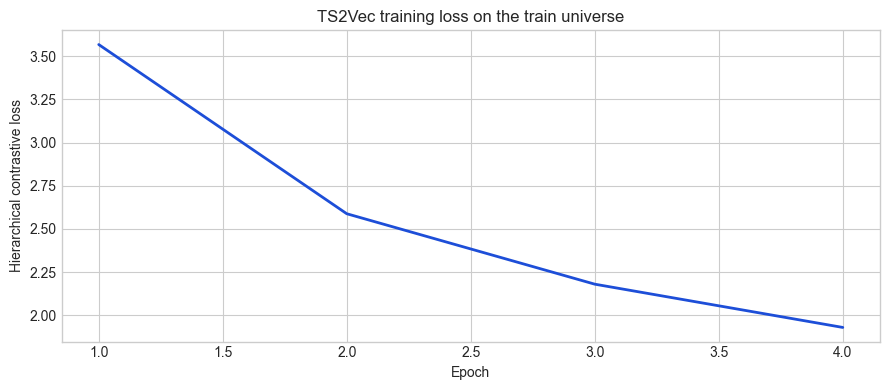

In [5]:

model, loss_log = fit_ts2vec(X_train)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(loss_log) + 1), loss_log, color="#1d4ed8", linewidth=2)
ax.set_title("TS2Vec training loss on the train universe")
ax.set_xlabel("Epoch")
ax.set_ylabel("Hierarchical contrastive loss")
plt.tight_layout()

display(
    pd.DataFrame(
        [
            {
                "device": DEVICE,
                "n_train_markets": int(len(X_train)),
                "lookback_hours": LOOKBACK_HOURS,
                "grid_hours": GRID_HOURS,
                "n_epochs": N_EPOCHS,
                "output_dims": OUTPUT_DIMS,
                "hidden_dims": HIDDEN_DIMS,
                "depth": DEPTH,
                "batch_size": BATCH_SIZE,
                "final_loss": float(loss_log[-1]),
            }
        ]
    )
)



## 4. Encode Full-Series And Window-Level Representations

We use two embedding levels:

- **full-series embeddings** for global clustering and outlier detection
- **early / middle / late pooled window embeddings** for regime-shift diagnostics

This keeps the anomaly analysis aligned with the TS2Vec paper's timestamp-level representation idea without storing all timestamp embeddings in memory at once.


,k,inertia,calinski_harabasz,davies_bouldin,ch_rank,db_rank,combined_rank
0,4,5464.585938,613.788007,1.117539,1.0,2.0,3.0
1,5,4668.955566,602.117245,1.163563,2.0,5.0,7.0
2,6,4080.387939,593.905862,1.126302,3.0,3.0,6.0
3,7,3646.268799,583.101119,1.095453,4.0,1.0,5.0
4,8,3318.884277,569.760059,1.149973,5.0,4.0,9.0


,cluster,n,start_mean,end_mean,path_range_mean,realized_vol_mean,max_abs_step_mean,breakout_score_mean,reversal_index_mean,pump_and_revert_score_mean,coinflip_share_mean,last_day_change_mean,early_late_drift_mean,late_shift_mean,named_regime,template_score
0,3,135,0.177489,0.179364,0.232441,0.023508,0.149894,0.000471,0.092655,0.092656,0.103215,0.000600,0.643079,0.554172,late_breakout,0.278439
1,2,3241,0.106330,0.029259,0.175966,0.016471,0.105915,-0.051586,0.075347,0.075348,0.012995,-0.004153,0.515311,0.374979,noisy_coinflip,-0.336035
2,1,2934,0.419692,0.415330,0.360115,0.054077,0.224868,-0.001948,0.138221,0.138222,0.270354,-0.000206,0.227003,0.163853,pump_and_revert,0.436355
3,0,2229,0.012096,0.002628,0.021210,0.002485,0.017064,-0.004542,0.010279,0.010280,0.000159,-0.000355,0.339983,0.228054,stable_no,2.175002
4,4,1617,0.560898,0.606546,0.299894,0.024810,0.164950,0.036947,0.139934,0.139934,0.233741,0.002722,0.220483,0.157459,stable_yes,0.877504


,named_regime,n,stable_end_mean,mean_range,mean_vol,mean_reversal,mean_breakout,mean_late_shift
0,late_breakout,135,0.179364,0.232441,0.023508,0.092655,0.000471,0.554172
1,noisy_coinflip,3241,0.029259,0.175966,0.016471,0.075347,-0.051586,0.374979
2,pump_and_revert,2934,0.415330,0.360115,0.054077,0.138221,-0.001948,0.163853
3,stable_no,2229,0.002628,0.021210,0.002485,0.010279,-0.004542,0.228054
4,stable_yes,1617,0.606546,0.299894,0.024810,0.139934,0.036947,0.157459


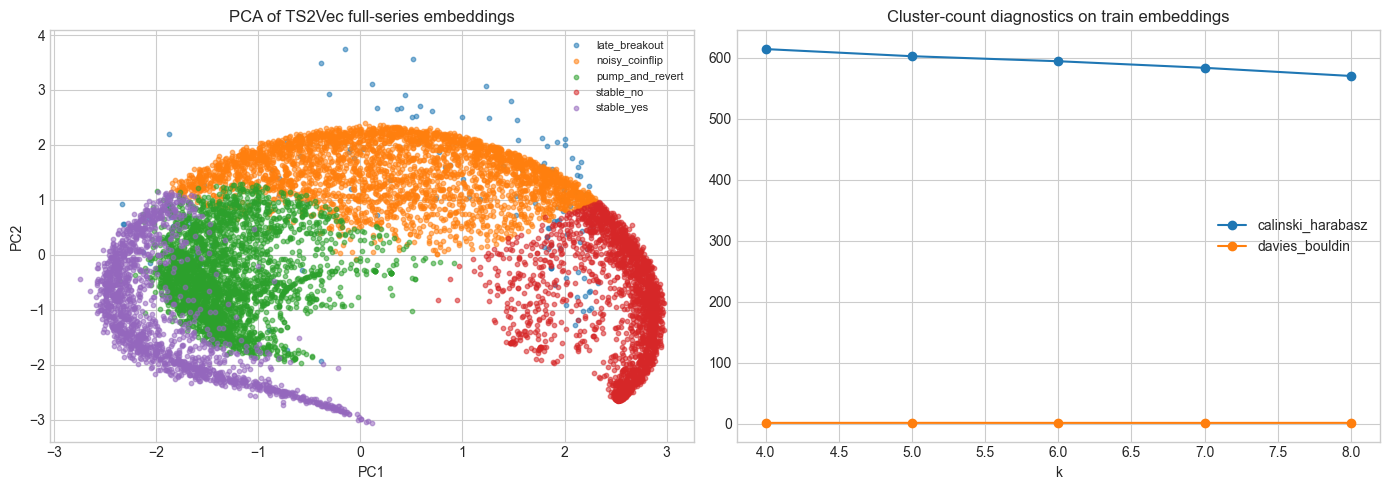

In [6]:

train_repr = batched_encode_full_series(model, X_train, batch_size=ENCODE_BATCH_SIZE)
analysis_repr = batched_encode_full_series(model, X_analysis, batch_size=ENCODE_BATCH_SIZE)
window_repr = batched_encode_window_poolings(model, X_analysis, valid_analysis, batch_size=ENCODE_BATCH_SIZE)

cluster_diagnostics = choose_cluster_count(
    train_repr,
    REGIME_CLUSTER_CANDIDATES,
    sample_size=min(CLUSTER_SELECTION_SAMPLE, len(train_repr)),
    seed=SEED,
)
regime_model = KMeans(n_clusters=FINAL_REGIME_K, random_state=SEED, n_init=50)
regime_model.fit(train_repr)
analysis_clusters = regime_model.predict(analysis_repr)

analysis_frame = build_market_feature_frame(analysis_meta, price_analysis, valid_analysis)
analysis_frame["regime_cluster"] = analysis_clusters
analysis_frame["distance_to_centroid"] = regime_model.transform(analysis_repr).min(axis=1)
analysis_frame["early_late_drift"] = [
    cosine_distance(a, b) for a, b in zip(window_repr["early"], window_repr["late"])
]
analysis_frame["mid_late_drift"] = [
    cosine_distance(a, b) for a, b in zip(window_repr["mid"], window_repr["late"])
]
analysis_frame["late_shift"] = 0.5 * (analysis_frame["early_late_drift"] + analysis_frame["mid_late_drift"])

cluster_summary = (
    analysis_frame.groupby("regime_cluster", dropna=False)
    .agg(
        n=("market_id", "size"),
        start_mean=("start_price", "mean"),
        end_mean=("end_price", "mean"),
        path_range_mean=("path_range", "mean"),
        realized_vol_mean=("realized_vol", "mean"),
        max_abs_step_mean=("max_abs_step", "mean"),
        breakout_score_mean=("breakout_score", "mean"),
        reversal_index_mean=("reversal_index", "mean"),
        pump_and_revert_score_mean=("pump_and_revert_score", "mean"),
        coinflip_share_mean=("coinflip_share", "mean"),
        last_day_change_mean=("last_day_change", "mean"),
        early_late_drift_mean=("early_late_drift", "mean"),
        late_shift_mean=("late_shift", "mean"),
    )
    .reset_index()
    .rename(columns={"regime_cluster": "cluster"})
)

regime_assignments, assignment_scores = assign_named_regimes(cluster_summary)
analysis_frame["named_regime"] = analysis_frame["regime_cluster"].map(regime_assignments)
cluster_summary["named_regime"] = cluster_summary["cluster"].map(regime_assignments)
cluster_summary = cluster_summary.merge(assignment_scores, on=["cluster", "named_regime"], how="left")

regime_summary = (
    analysis_frame.groupby("named_regime", dropna=False)
    .agg(
        n=("market_id", "size"),
        stable_end_mean=("end_price", "mean"),
        mean_range=("path_range", "mean"),
        mean_vol=("realized_vol", "mean"),
        mean_reversal=("reversal_index", "mean"),
        mean_breakout=("breakout_score", "mean"),
        mean_late_shift=("late_shift", "mean"),
    )
    .reset_index()
    .sort_values("named_regime")
)

pca = PCA(n_components=2, random_state=SEED)
analysis_coords = pca.fit_transform(analysis_repr)
analysis_frame["pc1"] = analysis_coords[:, 0]
analysis_frame["pc2"] = analysis_coords[:, 1]

display(cluster_diagnostics)
display(cluster_summary.sort_values("named_regime").reset_index(drop=True))
display(regime_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for regime_name, subset in analysis_frame.groupby("named_regime"):
    axes[0].scatter(subset["pc1"], subset["pc2"], s=10, alpha=0.55, label=regime_name)
axes[0].set_title("PCA of TS2Vec full-series embeddings")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(loc="best", fontsize=8)

cluster_diagnostics.plot(x="k", y=["calinski_harabasz", "davies_bouldin"], marker="o", ax=axes[1])
axes[1].set_title("Cluster-count diagnostics on train embeddings")
axes[1].set_xlabel("k")
plt.tight_layout()



## 5. Regime Gallery: What The Named Embedding Clusters Look Like

The clustering is fit in embedding space, but interpretation is done on the raw trajectories. This is the correct order:

1. learn the geometry from TS2Vec
2. cluster the geometry with `KMeans`
3. interpret each cluster by average path shape and representative markets

So the regime names are **post hoc labels**, not targets leaked into training. If cluster `2` happens to have high terminal probability, low range, and low coinflip occupancy, we may call it `stable_yes` afterward. That naming step is analysis, not supervision.


,cluster,market_id,split,named_regime,start_price,end_price,path_range,question
0,4,586571,train,stable_yes,0.730113,0.610000,0.180000,Will GL/PvdA be part of the next Government of the Netherlands?
1,4,518738,train,stable_yes,0.650000,0.680000,0.160000,Will Chappell Roan win Best New Artist?
2,4,549327,train,stable_yes,0.680000,0.660000,0.250000,Will the chopsticks catch SpaceX Starship Flight Test 10 Superheavy booster?
3,4,563790,train,stable_yes,0.710000,0.770000,0.220000,Will Zohran Mamdani win 4 boroughs in the 2025 New York City Mayoral General Election?
4,4,570384,train,stable_yes,0.740000,0.640000,0.120000,"Will Powell say ""Goal"" 15+ times during September press conference?"
5,0,683282,train,stable_no,0.010000,0.001000,0.009000,Will Gregory Mugisha Muntuyera win the 2026 Ugandan presidential election?
6,0,910072,train,stable_no,0.021000,0.001000,0.020000,Will Elon Musk's net worth be less than $440b on December 31?
7,0,664737,train,stable_no,0.008000,0.001000,0.010000,Will MrBeast hit 490 million subscribers by December 31?
8,0,564322,train,stable_no,0.005903,0.003000,0.007000,Will What We Do in the Shadows win the Emmy for Outstanding Comedy Series?
9,0,595364,train,stable_no,0.006000,0.005000,0.005000,Databricks IPO in 2025?


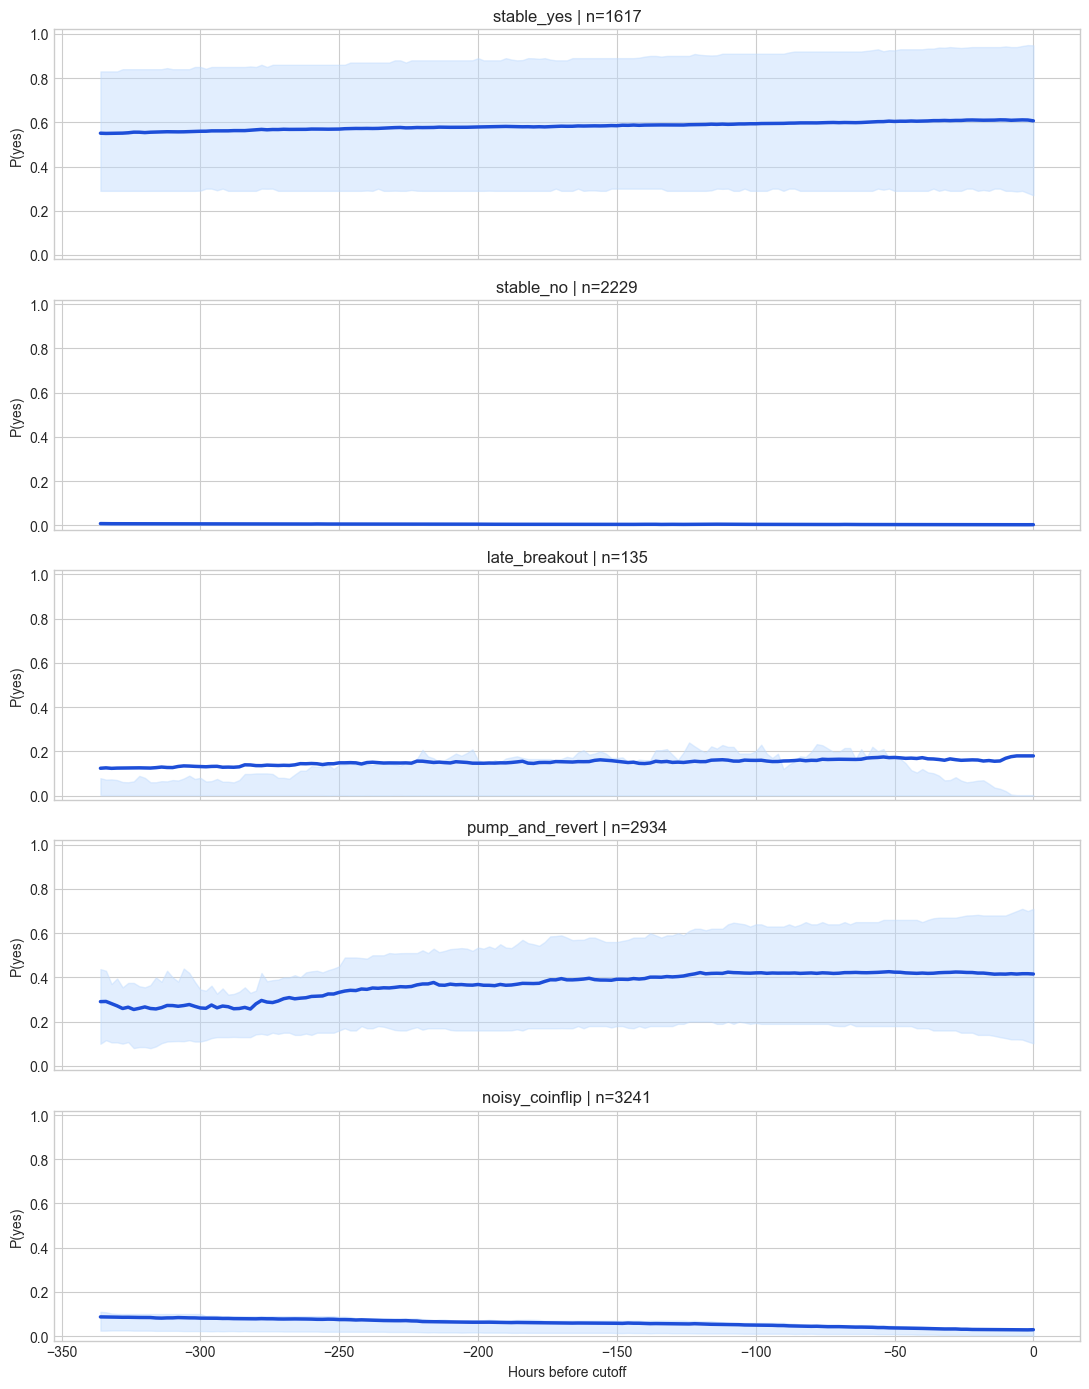

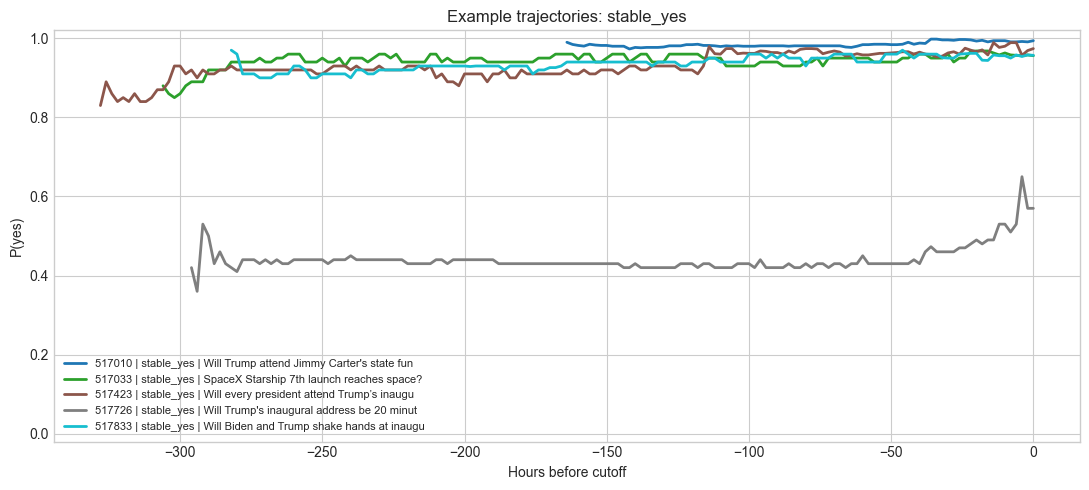

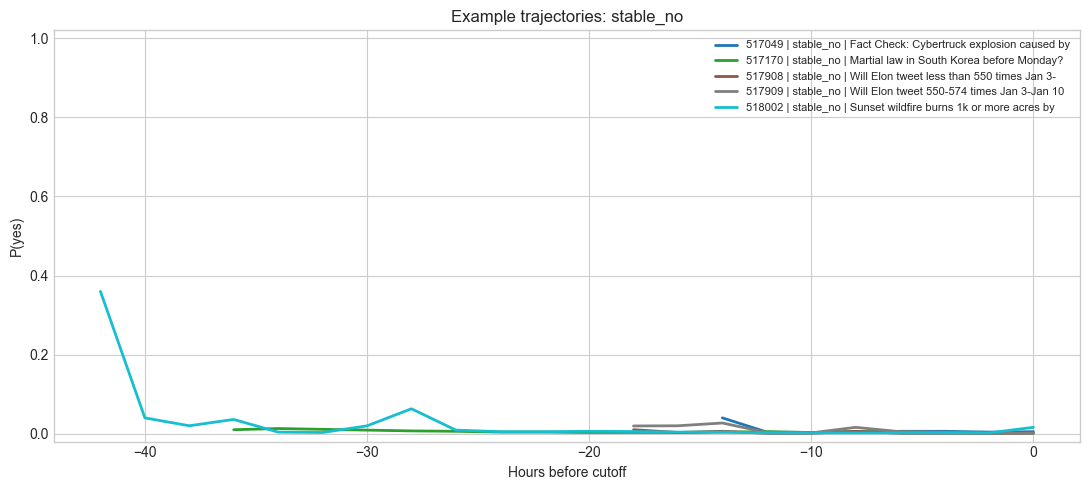

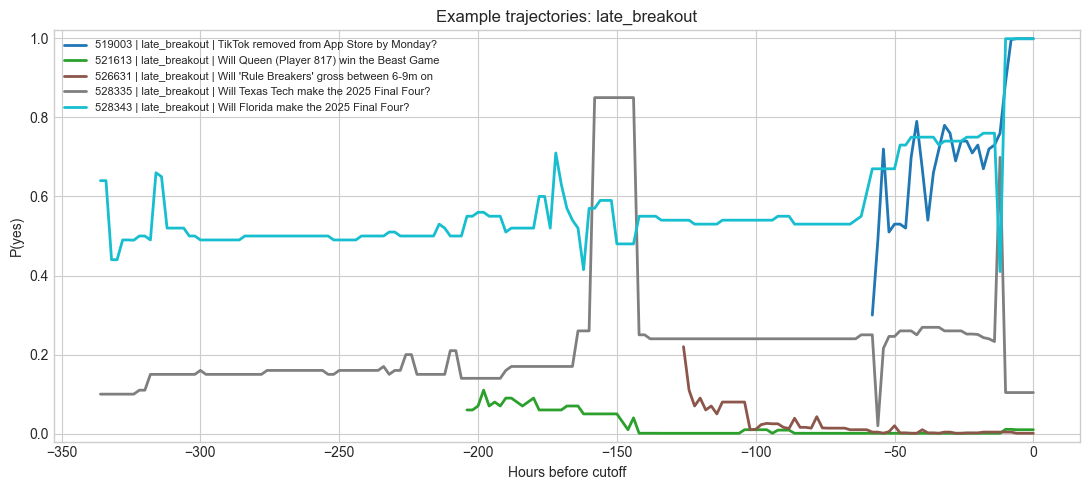

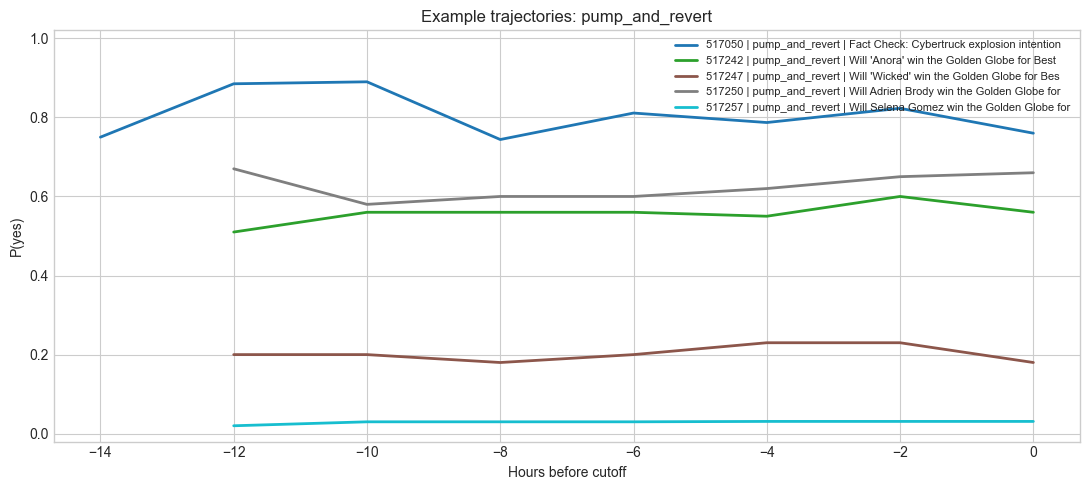

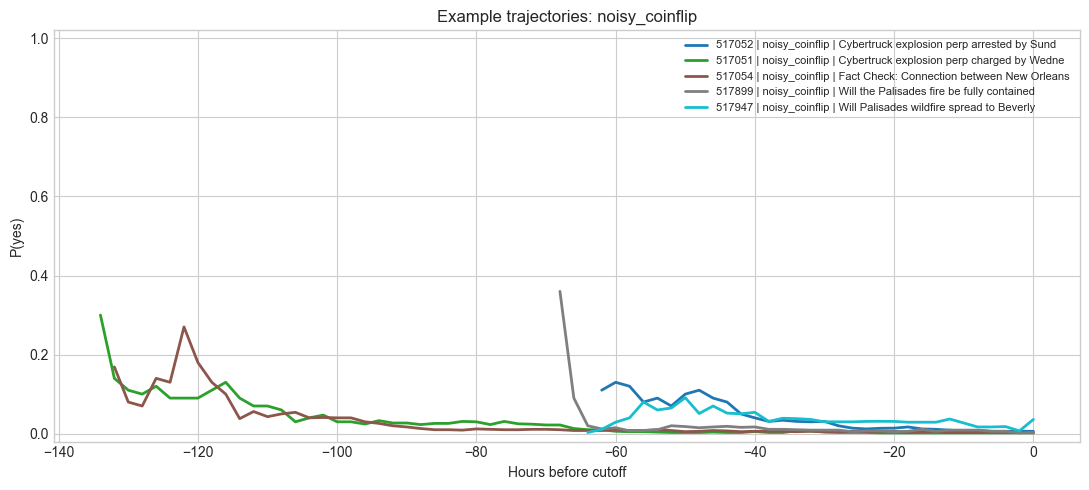

In [7]:

regime_order = [name for name in REGIME_NAMES if name in set(analysis_frame["named_regime"])]
fig, axes = plt.subplots(len(regime_order), 1, figsize=(11, 2.8 * len(regime_order)), sharex=True)
if len(regime_order) == 1:
    axes = [axes]

for ax, regime_name in zip(axes, regime_order):
    idx = analysis_frame.index[analysis_frame["named_regime"] == regime_name].to_numpy()
    regime_prices = price_analysis[idx]
    mean_path = np.nanmean(regime_prices, axis=0)
    p25 = np.nanpercentile(regime_prices, 25, axis=0)
    p75 = np.nanpercentile(regime_prices, 75, axis=0)
    ax.fill_between(HOURS_AXIS, p25, p75, color="#bfdbfe", alpha=0.45)
    ax.plot(HOURS_AXIS, mean_path, color="#1d4ed8", linewidth=2.5)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("P(yes)")
    ax.set_title(f"{regime_name} | n={len(idx)}")
axes[-1].set_xlabel("Hours before cutoff")
plt.tight_layout()

representative_rows = []
centroid_distances = regime_model.transform(analysis_repr)
for cluster_id, regime_name in regime_assignments.items():
    members = analysis_frame.index[analysis_frame["regime_cluster"] == cluster_id].to_numpy()
    nearest = members[np.argsort(centroid_distances[members, cluster_id])[:TOP_REPRESENTATIVES]]
    reps = analysis_frame.iloc[nearest].loc[:, [
        "market_id",
        "split",
        "named_regime",
        "start_price",
        "end_price",
        "path_range",
        "question",
    ]].copy()
    reps.insert(0, "cluster", cluster_id)
    representative_rows.append(reps)
representatives = pd.concat(representative_rows, ignore_index=True)
display(representatives)

for regime_name in regime_order:
    members = analysis_frame.index[analysis_frame["named_regime"] == regime_name].to_numpy()
    exemplar_idx = members[: min(5, len(members))]
    plot_market_paths(
        analysis_frame,
        price_analysis,
        valid_analysis,
        exemplar_idx,
        title=f"Example trajectories: {regime_name}",
    )



## 6. Embedding-Native Anomaly And Regime-Shift Detection

We build three anomaly families.

1. `sharp_move_score`
   Markets with unusually large jumps plus strong late-window embedding drift.
2. `reversal_anomaly_score`
   Markets with large excursion, weak net displacement, and a strong early-to-late regime change.
3. `weird_late_score`
   Markets that are globally atypical in embedding space and also diverge sharply in the final window.

This is intentionally hybrid:

- **embedding distances** decide whether a path is globally unusual
- **window embedding drift** detects regime shifts
- **raw path shape metrics** determine which kind of anomaly it is


/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,market_id,split,named_regime,end_price,path_range,max_abs_step,pump_and_revert_score,late_shift,lof_score,question,sharp_move_score
0,567143,train,stable_no,0.001,0.001000,0.001000,1.000000e-03,0.110684,6.254483e+08,Will Thaddeus Whelan win the 2025 Seattle mayoral election?,32.748339
1,522531,train,pump_and_revert,0.999,0.969000,0.929813,1.700009e-01,0.876930,1.032791e+00,Kanye back on X by Friday?,13.624391
2,526675,train,stable_no,0.001,0.000161,0.000161,1.607144e-04,0.110641,2.739508e+08,Will the New Democratic Party win the popular vote in Canada's next election?,13.396575
3,1032227,test,noisy_coinflip,0.964,0.962000,0.920000,1.950008e-01,0.896577,1.162205e+00,"Will Gold (GC) settle at $4,725-$4,850 in January?",12.879603
4,1032319,test,stable_yes,0.010,0.989000,0.977000,3.790006e-01,0.345238,1.229612e+00,Will Silver (SI) settle over $85 on the final trading day of January 2026?,11.142645
5,550766,train,pump_and_revert,0.999,0.919000,0.775000,6.563205e-02,0.558050,1.003942e+00,Trump x Elon talk by Friday?,11.044228
6,535350,train,pump_and_revert,0.796,0.816000,0.816000,3.000094e-02,0.698930,1.604280e+00,Will 'King of Kings' make between $18-21m on its domestic opening weekend?,11.005458
7,648390,train,pump_and_revert,0.999,0.949000,0.949000,1.000010e-01,0.270511,1.436129e+00,Will Trump strike a drug boat on October 29?,10.799586
8,1032300,test,stable_yes,0.024,0.975000,0.951000,4.090006e-01,0.311233,1.189638e+00,Will Silver (SI) settle at >$85 in January?,10.775944
9,1032318,test,stable_yes,0.020,0.978000,0.930000,5.480005e-01,0.332654,1.236827e+00,Will Silver (SI) settle over $90 on the final trading day of January 2026?,10.683316


,market_id,split,named_regime,end_price,path_range,max_abs_step,pump_and_revert_score,late_shift,lof_score,question,reversal_anomaly_score
0,567143,train,stable_no,0.001000,0.001000,0.001000,0.001000,0.110684,6.254483e+08,Will Thaddeus Whelan win the 2025 Seattle mayoral election?,32.792887
1,1032230,test,noisy_coinflip,0.002000,0.969000,0.333000,0.952000,0.749398,1.290687e+00,"Will Gold (GC) settle at >$5,100 in January?",13.723796
2,526675,train,stable_no,0.001000,0.000161,0.000161,0.000161,0.110641,2.739508e+08,Will the New Democratic Party win the popular vote in Canada's next election?,13.441714
3,1032247,test,noisy_coinflip,0.005000,0.934000,0.350000,0.868000,0.805479,1.163656e+00,"Will Gold (GC) settle over $5,200 on the final trading day of January 2026?",12.266939
4,541099,train,pump_and_revert,0.970000,0.973000,0.860000,0.963000,0.414300,1.073540e+00,Pakistan military strike on India by Friday?,11.820806
5,1693777,test,stable_no,0.001000,0.959000,0.950000,0.950000,0.320594,1.514007e+00,"Will ""Stateside - PinkPantheress With Zara Larsson"" be the Billboard #1 song for the week of April 4?",11.743923
6,521619,train,pump_and_revert,0.051000,0.968000,0.938000,0.949000,0.381729,1.175957e+00,Will Gage (Player 974) win the Beast Games?,11.600543
7,528832,train,stable_no,0.003834,0.982000,0.977000,0.981166,0.246554,1.710455e+00,Avail airdrop in Q2 2025?,11.447838
8,1032246,test,noisy_coinflip,0.005000,0.891000,0.846000,0.877242,0.496803,1.205760e+00,"Will Gold (GC) settle over $5,500 on the final trading day of January 2026?",11.399582
9,1032248,test,stable_yes,0.010469,0.973531,0.877531,0.853000,0.496440,1.276231e+00,"Will Gold (GC) settle over $5,000 on the final trading day of January 2026?",11.218116


,market_id,split,named_regime,end_price,path_range,max_abs_step,pump_and_revert_score,late_shift,lof_score,question,weird_late_score
0,657441,train,late_breakout,0.001,0.95900,0.650000,0.240001,0.523048,1.122221,Will Israel strike 1 country in November 2025?,20.037783
1,522531,train,pump_and_revert,0.999,0.96900,0.929813,0.170001,0.876930,1.032791,Kanye back on X by Friday?,15.498609
2,528335,train,late_breakout,0.104,0.83000,0.600000,0.826000,0.492262,1.144804,Will Texas Tech make the 2025 Final Four?,14.838608
3,540270,train,late_breakout,0.999,0.93900,0.939000,0.850000,0.314964,1.280793,Will the Pittsburgh Steelers win the AFC North?,14.261466
4,539446,train,late_breakout,0.001,0.07900,0.078000,0.040000,1.082351,1.087913,Will Rodriguez win the 2025 Kentucky Derby?,14.252881
5,1628482,test,late_breakout,0.999,0.37900,0.130000,0.090000,0.495511,1.027121,"Will Iran conduct a military action against Israel on March 29, 2026?",14.171507
6,538746,train,late_breakout,0.001,0.76900,0.390000,0.390000,0.515550,1.072947,Will Lando Norris win the 2025 Miami GP pole?,13.858733
7,539448,train,late_breakout,0.001,0.09600,0.053000,0.057000,0.843242,1.038695,Will Burnham Square win the 2025 Kentucky Derby?,13.731556
8,1633175,test,late_breakout,0.999,0.77900,0.650000,0.430000,0.412896,1.061614,"Will Israel take military action in Gaza on March 29, 2026?",13.622100
9,552470,train,late_breakout,0.999,0.85900,0.841000,0.280000,0.442155,0.988013,"Will Trump say ""Big beautiful deal"" this week?",13.517608


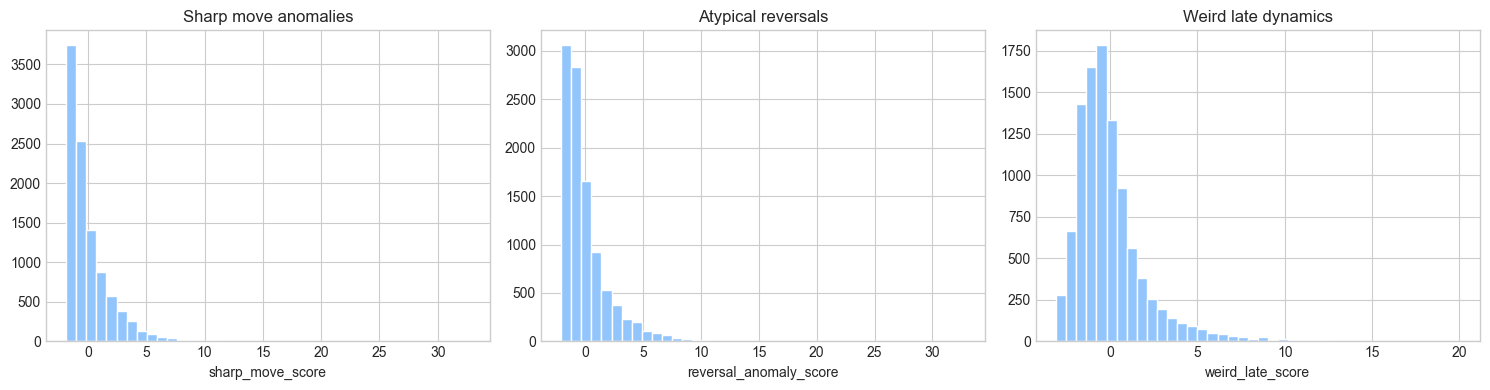

In [8]:

analysis_frame, knn_distances, knn_indices = nearest_neighbor_tables(
    analysis_repr,
    analysis_frame,
    n_neighbors=min(KNN_NEIGHBORS, len(analysis_frame) - 1),
)

lof = LocalOutlierFactor(n_neighbors=min(KNN_NEIGHBORS, len(analysis_frame) - 1), metric="euclidean")
lof_labels = lof.fit_predict(analysis_repr)
analysis_frame["lof_score"] = -lof.negative_outlier_factor_
analysis_frame["lof_flag"] = lof_labels == -1

analysis_frame["sharp_move_score"] = (
    1.0 * zscore_series(analysis_frame["max_abs_step"]) +
    0.8 * zscore_series(analysis_frame["last_day_range"]) +
    0.8 * zscore_series(analysis_frame["mid_late_drift"]) +
    0.4 * zscore_series(analysis_frame["lof_score"])
)
analysis_frame["reversal_anomaly_score"] = (
    1.0 * zscore_series(analysis_frame["pump_and_revert_score"]) +
    0.8 * zscore_series(analysis_frame["reversal_index"]) +
    0.8 * zscore_series(analysis_frame["early_late_drift"]) +
    0.4 * zscore_series(analysis_frame["lof_score"])
)
analysis_frame["weird_late_score"] = (
    1.0 * zscore_series(analysis_frame["distance_to_centroid"]) +
    0.8 * zscore_series(analysis_frame["mean_knn_distance"]) +
    0.8 * zscore_series(analysis_frame["mid_late_drift"]) +
    0.5 * zscore_series(analysis_frame["last_day_change"].abs())
)

sharp_moves = analysis_frame.sort_values("sharp_move_score", ascending=False).head(TOP_ANOMALIES).reset_index(drop=True)
reversals = analysis_frame.sort_values("reversal_anomaly_score", ascending=False).head(TOP_ANOMALIES).reset_index(drop=True)
weird_late = analysis_frame.sort_values("weird_late_score", ascending=False).head(TOP_ANOMALIES).reset_index(drop=True)

cols = [
    "market_id",
    "split",
    "named_regime",
    "end_price",
    "path_range",
    "max_abs_step",
    "pump_and_revert_score",
    "late_shift",
    "lof_score",
    "question",
]

display(sharp_moves.loc[:, cols + ["sharp_move_score"]])
display(reversals.loc[:, cols + ["reversal_anomaly_score"]])
display(weird_late.loc[:, cols + ["weird_late_score"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, score_col, title in [
    (axes[0], "sharp_move_score", "Sharp move anomalies"),
    (axes[1], "reversal_anomaly_score", "Atypical reversals"),
    (axes[2], "weird_late_score", "Weird late dynamics"),
]:
    ax.hist(analysis_frame[score_col], bins=40, color="#93c5fd", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(score_col)
plt.tight_layout()



## 7. Plot The Top Anomaly Families And Compare To Nearest Neighbors

For presentation use, the most convincing visual pattern is:

- show the top path in each anomaly family
- then show its nearest neighbors in TS2Vec embedding space
- explain whether the anomaly is a rare version of a familiar regime or a genuinely isolated trajectory


,market_id,split,named_regime,start_price,end_price,path_range,late_shift,sharp_move_score,question
5246,567143,train,stable_no,0.001,0.001,0.001,0.110684,32.748339,Will Thaddeus Whelan win the 2025 Seattle mayoral election?


,distance,market_id,split,named_regime,end_price,path_range,question
0,0.076595,526675,train,stable_no,0.001,1.607144e-04,Will the New Democratic Party win the popular vote in Canada's next election?
1,0.087775,567122,train,stable_no,0.001,1.000000e-03,Will Althea Garrison win the 2025 Boston mayoral election?
2,0.088018,530905,train,stable_no,0.001,1.000000e-03,Will the Bloc Québécois win the most seats in Alberta in the next Canadian Election?
3,0.104768,577934,train,stable_no,0.001,6.495975e-08,Will 'A Minecraft Movie' have the third best domestic opening weekend in 2025?
4,0.104785,517588,train,stable_no,0.001,0.000000e+00,Will the New Democratic Party win the most seats in the next Canadian election?


,market_id,split,named_regime,start_price,end_price,path_range,late_shift,reversal_anomaly_score,question
5246,567143,train,stable_no,0.001,0.001,0.001,0.110684,32.792887,Will Thaddeus Whelan win the 2025 Seattle mayoral election?


,distance,market_id,split,named_regime,end_price,path_range,question
0,0.076595,526675,train,stable_no,0.001,1.607144e-04,Will the New Democratic Party win the popular vote in Canada's next election?
1,0.087775,567122,train,stable_no,0.001,1.000000e-03,Will Althea Garrison win the 2025 Boston mayoral election?
2,0.088018,530905,train,stable_no,0.001,1.000000e-03,Will the Bloc Québécois win the most seats in Alberta in the next Canadian Election?
3,0.104768,577934,train,stable_no,0.001,6.495975e-08,Will 'A Minecraft Movie' have the third best domestic opening weekend in 2025?
4,0.104785,517588,train,stable_no,0.001,0.000000e+00,Will the New Democratic Party win the most seats in the next Canadian election?


,market_id,split,named_regime,start_price,end_price,path_range,late_shift,weird_late_score,question
5751,657441,train,late_breakout,0.72,0.001,0.959,0.523048,20.037783,Will Israel strike 1 country in November 2025?


,distance,market_id,split,named_regime,end_price,path_range,question
0,2.437826,538746,train,late_breakout,0.001,0.769,Will Lando Norris win the 2025 Miami GP pole?
1,3.321465,528335,train,late_breakout,0.104,0.830,Will Texas Tech make the 2025 Final Four?
2,3.378388,1628482,test,late_breakout,0.999,0.379,"Will Iran conduct a military action against Israel on March 29, 2026?"
3,3.636225,528343,train,late_breakout,0.999,0.589,Will Florida make the 2025 Final Four?
4,3.673899,1389075,test,late_breakout,0.999,0.459,"US x Iran meeting by March 31, 2026?"


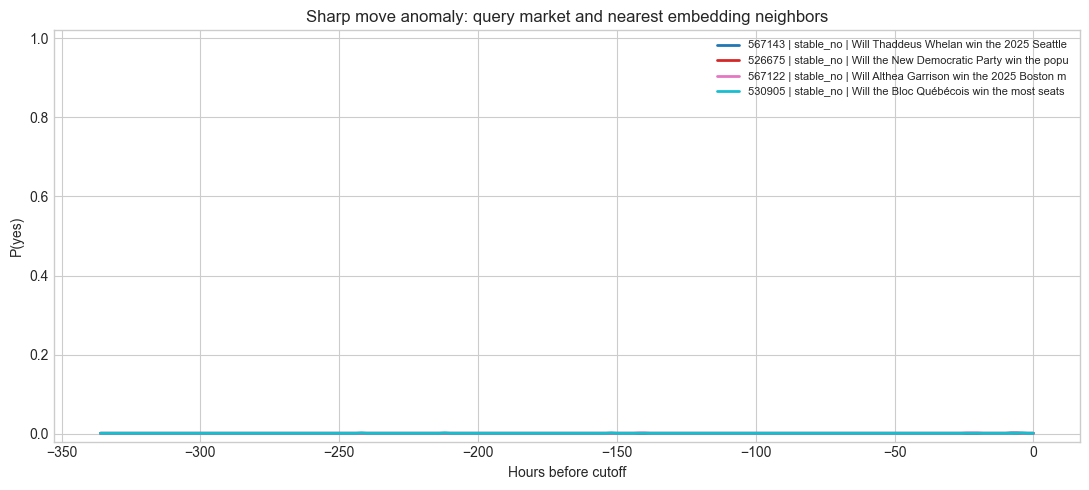

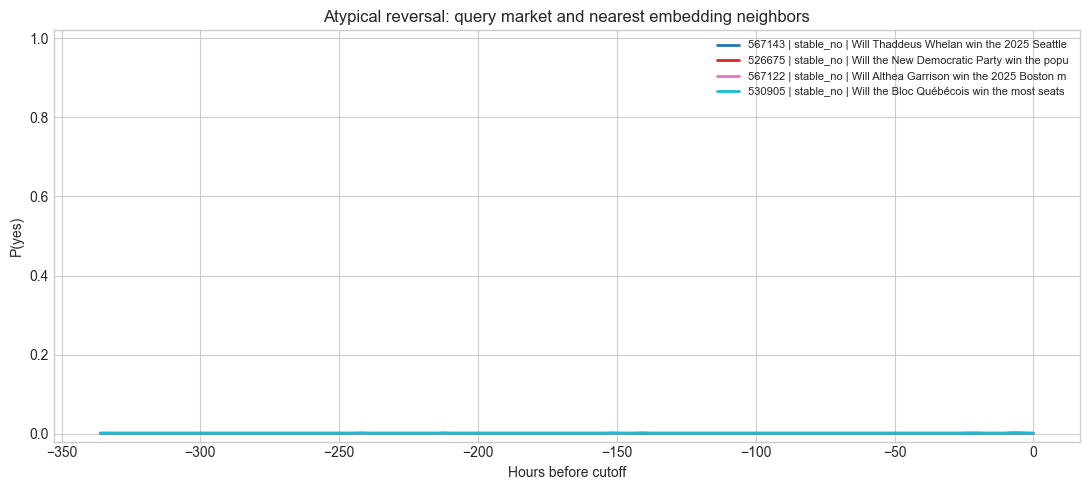

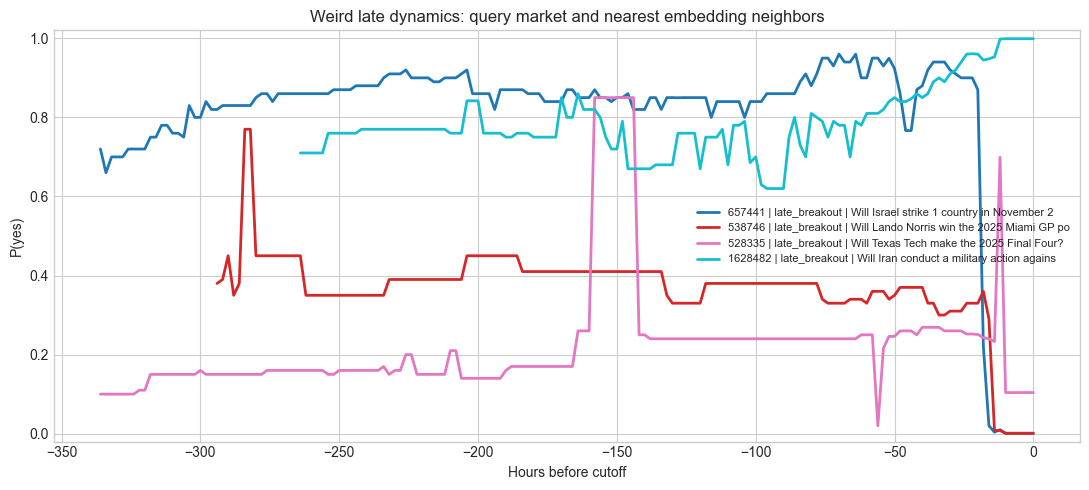

In [9]:

anomaly_specs = [
    ("sharp_move_score", "Sharp move anomaly"),
    ("reversal_anomaly_score", "Atypical reversal"),
    ("weird_late_score", "Weird late dynamics"),
]

for score_col, title in anomaly_specs:
    row_idx = int(analysis_frame[score_col].idxmax())
    display(
        analysis_frame.loc[[row_idx], [
            "market_id",
            "split",
            "named_regime",
            "start_price",
            "end_price",
            "path_range",
            "late_shift",
            score_col,
            "question",
        ]]
    )
    display(
        anomaly_neighbor_table(
            row_idx,
            analysis_frame,
            knn_indices,
            knn_distances,
            top_k=ANOMALY_NEIGHBORS,
        )
    )
    neighbor_ids = knn_indices[row_idx][: min(3, len(knn_indices[row_idx]))]
    plot_market_paths(
        analysis_frame,
        price_analysis,
        valid_analysis,
        [row_idx, *neighbor_ids.tolist()],
        title=f"{title}: query market and nearest embedding neighbors",
    )



## 8. Suggested Interpretation For A Paper-Style Discussion

This experiment is most convincing when framed as **representation learning for market dynamics**, not as a proxy classifier for terminal outcomes.

Questions the notebook is meant to answer:

- Does TS2Vec recover a stable regime geometry from Polymarket price paths?
- Are the five named regimes visible as coherent regions in embedding space?
- Do anomaly scores reveal rare trajectories that are not obvious from the last price alone?
- Are sharp moves and reversals better understood as **regime transitions** rather than just large scalar deltas?


In [10]:

summary_lines = [
    "### Presentation framing",
    "- The trained TS2Vec encoder is used here as a market-trajectory representation model, not as a terminal classifier.",
    "- The primary downstream task is regime discovery: stable yes, stable no, late breakout, pump-and-revert, and noisy coinflip.",
    "- The anomaly layer then asks which markets are globally rare in embedding space and which ones undergo unusually large late-stage regime shifts.",
    "- The full-series embedding captures overall trajectory type, while pooled early/mid/late window embeddings expose regime drift through time.",
    "- This makes the notebook a much more natural TS2Vec application than direct resolved-outcome prediction, because the object of interest is the shape of the path itself.",
    "- When you present results, emphasize geometry, representative markets, and anomaly galleries rather than single scalar benchmark metrics.",
]

display(Markdown("\n".join(summary_lines)))


### Presentation framing
- The trained TS2Vec encoder is used here as a market-trajectory representation model, not as a terminal classifier.
- The primary downstream task is regime discovery: stable yes, stable no, late breakout, pump-and-revert, and noisy coinflip.
- The anomaly layer then asks which markets are globally rare in embedding space and which ones undergo unusually large late-stage regime shifts.
- The full-series embedding captures overall trajectory type, while pooled early/mid/late window embeddings expose regime drift through time.
- This makes the notebook a much more natural TS2Vec application than direct resolved-outcome prediction, because the object of interest is the shape of the path itself.
- When you present results, emphasize geometry, representative markets, and anomaly galleries rather than single scalar benchmark metrics.